# Ad Click Prediction Using Deep Learning

***Student Name -
Suhadev Srinivasan***



***Project Overview***

**Online Advertisement Click Prediction Using Deep Learning**

**1. Project Title - Online Advertisement Click-Through Rate (CTR) Prediction Using Deep Learning**

**2. Domain - Digital Marketing / Advertising Analytics / Machine Learning / Deep Learning**

**3. Project Type - Binary Classification — Deep Learning Capstone Project**

**4. Project Objective - The objective of this project is to develop a Deep Learning model that predicts whether a user will click on an online advertisement based on user characteristics, advertisement information, device details, campaign information, and user engagement behavior.**

***WORKFLOW***

                    DEEP LEARNING CAPSTONE
              ONLINE ADVERTISEMENT CLICK PREDICTION
                              │
                              ▼
                  1. Problem Definition
                              │
                              ▼
                  2. Business Understanding
                              │
                              ▼
                  3. Data Collection
                              │
                              ▼
                  4. Data Loading
                              │
                              ▼
                  5. Data Understanding
                              │
                              ▼
                  6. Data Cleaning
                              │
                              ▼
                  7. Exploratory Data Analysis
                              │
                              ▼
                  8. Feature Engineering
                              │
                              ▼
                  9. Feature Selection
                              │
                              ▼
                 10. Train / Validation / Test Split
                              │
                              ▼
                 11. Data Preprocessing
                       ┌──────┴──────┐
                       ▼             ▼
                 Numerical       Categorical
                  Scaling           Encoding
                       └──────┬──────┘
                              ▼
                 12. ML Baseline Models
                       ┌──────┴──────┐
                       ▼             ▼
                Logistic Reg.    Random Forest
                              │
                              ▼
                 13. Deep Learning Model
                              │
                              ▼
                    Neural Network
                              │
                              ▼
                 14. Model Training
                              │
                              ▼
                 15. Model Validation
                              │
                              ▼
                 16. Hyperparameter Tuning
                              │
                              ▼
                 17. Model Evaluation
                              │
              ┌───────────────┼───────────────┐
              ▼               ▼               ▼
           Accuracy        F1 / Recall     ROC-AUC
                              │
                              ▼
                 18. Error Analysis
                              │
                              ▼
                 19. Model Comparison
                              │
                              ▼
                 20. Save Best Model
                              │
                              ▼
                 21. Prediction Pipeline
                              │
                              ▼
                 22. Streamlit Deployment
                              │
                              ▼
                 23. Business Insights
                              │
                              ▼
                 24. Final Report
                              │
                              ▼
                 25. Presentation + GitHub

***Import Libraries***

In [33]:
!pip install tensorflow

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Load Dataset

In [36]:
file_path = "../data/ad_click_data.xlsx"

df = pd.read_excel(r"C:\Users\acer\Desktop\Ad Click Prediction Using DL\DATASET\Ad Click Prediction.xlsx")

df.head()

,user_id,age,gender,income,device_type,browser,location,ad_id,ad_category,ad_position,impressions,time_on_page,pages_viewed,previous_clicks,session_duration,hour,day_of_week,campaign_type,device_engagement,click
0,100001,22,Female,92988,Mobile,Safari,Ahmedabad,1084,Fashion,Middle,5,70.5,5,1,142.1,5,Wednesday,Conversion,61.36,1
1,100002,55,Male,67154,Mobile,Safari,Ahmedabad,1144,Entertainment,Bottom,7,34.7,5,2,86.4,6,Monday,Retargeting,54.64,1
2,100003,49,Female,64570,Mobile,Firefox,Pune,1084,Food,Middle,6,76.1,6,2,248.1,19,Tuesday,Awareness,58.99,1
3,100004,39,Male,87468,Mobile,Safari,Delhi,1110,Travel,Middle,5,12.9,4,1,22.6,6,Saturday,Awareness,33.00,1
4,100005,38,Female,103769,Mobile,Firefox,Pune,1005,Finance,Bottom,6,33.8,4,1,97.5,1,Monday,Retargeting,45.87,1


In [37]:
df.shape

(100000, 20)

***Understand the Data***

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            100000 non-null  int64  
 1   age                100000 non-null  int64  
 2   gender             100000 non-null  object 
 3   income             100000 non-null  int64  
 4   device_type        100000 non-null  object 
 5   browser            100000 non-null  object 
 6   location           100000 non-null  object 
 7   ad_id              100000 non-null  int64  
 8   ad_category        100000 non-null  object 
 9   ad_position        100000 non-null  object 
 10  impressions        100000 non-null  int64  
 11  time_on_page       100000 non-null  float64
 12  pages_viewed       100000 non-null  int64  
 13  previous_clicks    100000 non-null  int64  
 14  session_duration   100000 non-null  float64
 15  hour               100000 non-null  int64  
 16  day

In [39]:
df.columns

Index(['user_id', 'age', 'gender', 'income', 'device_type', 'browser',
       'location', 'ad_id', 'ad_category', 'ad_position', 'impressions',
       'time_on_page', 'pages_viewed', 'previous_clicks', 'session_duration',
       'hour', 'day_of_week', 'campaign_type', 'device_engagement', 'click'],
      dtype='object')

***Check missing values***

In [40]:
df.isnull().sum()

user_id              0
age                  0
gender               0
income               0
device_type          0
browser              0
location             0
ad_id                0
ad_category          0
ad_position          0
impressions          0
time_on_page         0
pages_viewed         0
previous_clicks      0
session_duration     0
hour                 0
day_of_week          0
campaign_type        0
device_engagement    0
click                0
dtype: int64

In [41]:
df.isna().sum().sum()

np.int64(0)

***Check duplicate records***

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df["user_id"].duplicated().sum()

np.int64(0)

***Analyze the target variable***

In [44]:
print(df["click"].value_counts())

click
0    65071
1    34929
Name: count, dtype: int64


In [45]:
print(df["click"].value_counts(normalize=True) * 100)

click
0    65.071
1    34.929
Name: proportion, dtype: float64


***Visualize target distribution***

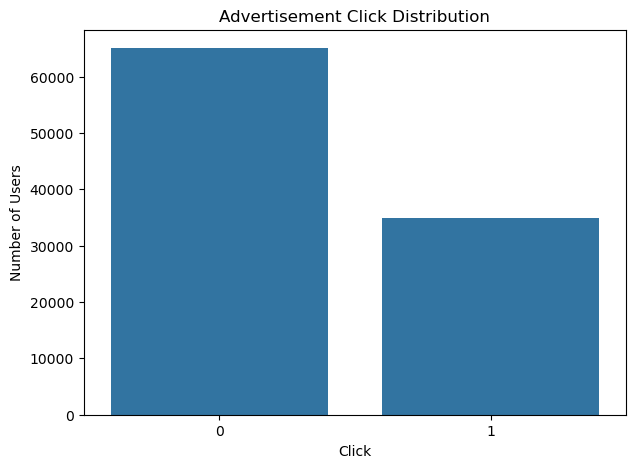

In [46]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="click")

plt.title("Advertisement Click Distribution")
plt.xlabel("Click")
plt.ylabel("Number of Users")

plt.show()

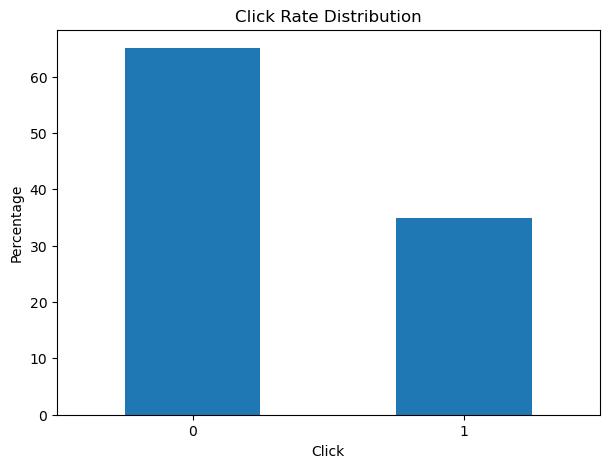

In [47]:
click_percentage = df["click"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))

click_percentage.plot(kind="bar")

plt.title("Click Rate Distribution")
plt.xlabel("Click")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

***Numerical feature analysis***

In [48]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns)

Index(['user_id', 'age', 'income', 'ad_id', 'impressions', 'time_on_page',
       'pages_viewed', 'previous_clicks', 'session_duration', 'hour',
       'device_engagement', 'click'],
      dtype='object')


***Statistical summary***

In [59]:
df.describe()

,user_id,age,income,ad_id,impressions,time_on_page,pages_viewed,previous_clicks,session_duration,hour,device_engagement,click
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,150000.500000,41.493910,65222.322410,1075.620900,5.001210,45.155386,3.995400,1.300880,135.658221,11.490950,51.985885,0.349290
std,28867.657797,13.853242,21635.085917,43.224979,2.009017,28.493640,1.732036,1.143208,97.526459,6.911727,10.980924,0.476748
min,100001.000000,18.000000,18000.000000,1001.000000,1.000000,3.000000,1.000000,0.000000,10.000000,0.000000,10.990000,0.000000
25%,125000.750000,29.000000,50325.750000,1038.000000,4.000000,24.100000,3.000000,0.000000,65.700000,6.000000,44.470000,0.000000
50%,150000.500000,42.000000,65188.500000,1076.000000,5.000000,39.400000,4.000000,1.000000,111.700000,11.000000,51.650000,0.000000
75%,175000.250000,53.000000,79901.000000,1113.000000,6.000000,59.800000,5.000000,2.000000,179.500000,17.000000,59.170000,1.000000
max,200000.000000,65.000000,174852.000000,1150.000000,16.000000,265.900000,14.000000,9.000000,1142.700000,23.000000,100.000000,1.000000


In [60]:
df.describe(include="object")

,gender,device_type,browser,location,ad_category,ad_position,day_of_week,campaign_type
count,100000,100000,100000,100000,100000,100000,100000,100000
unique,3,3,5,10,10,4,7,4
top,Female,Mobile,Chrome,Chennai,Technology,Middle,Tuesday,Consideration
freq,49008,58170,52355,10155,10128,35951,14388,30197


***Analyze categorical variables***

In [61]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Female    49008
Male      48013
Other      2979
Name: count, dtype: int64

 device_type
device_type
Mobile     58170
Desktop    29928
Tablet     11902
Name: count, dtype: int64

 browser
browser
Chrome     52355
Safari     22789
Firefox    11966
Edge        9872
Opera       3018
Name: count, dtype: int64

 location
location
Chennai       10155
Delhi         10082
Bengaluru     10048
Kolkata       10032
Pune          10018
Ahmedabad     10005
Hyderabad      9971
Mumbai         9922
Coimbatore     9920
Jaipur         9847
Name: count, dtype: int64

 ad_category
ad_category
Technology       10128
Travel           10071
Finance          10045
Healthcare       10042
Automotive       10027
Education        10007
Entertainment     9982
Fashion           9942
Food              9895
E-commerce        9861
Name: count, dtype: int64

 ad_position
ad_position
Middle     35951
Top        27964
Bottom     19985
Sidebar    16100
Name: count, dtype: int64

 day_of_week
day_of_week
Tues

***Analyze click rate by categories***

In [62]:
gender_ctr = df.groupby("gender")["click"].mean() * 100

print(gender_ctr)

gender
Female    34.816765
Male      34.988441
Other     35.817388
Name: click, dtype: float64


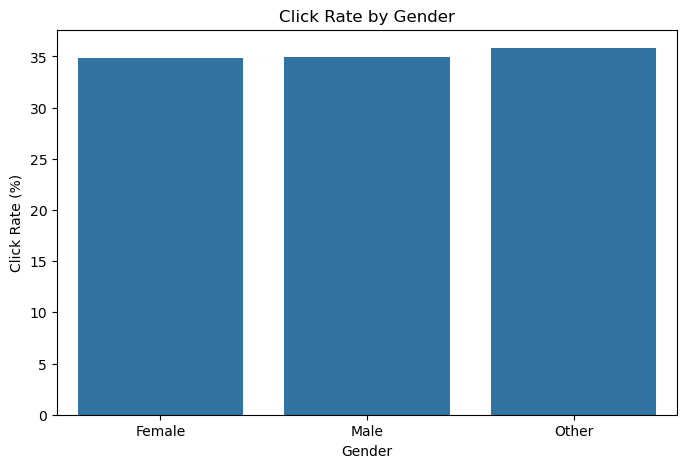

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=gender_ctr.index,
    y=gender_ctr.values
)

plt.title("Click Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Click Rate (%)")

plt.show()

***Click rate by device***

In [64]:
device_ctr = df.groupby("device_type")["click"].mean() * 100

print(device_ctr)

device_type
Desktop    32.972467
Mobile     36.338319
Tablet     32.960847
Name: click, dtype: float64


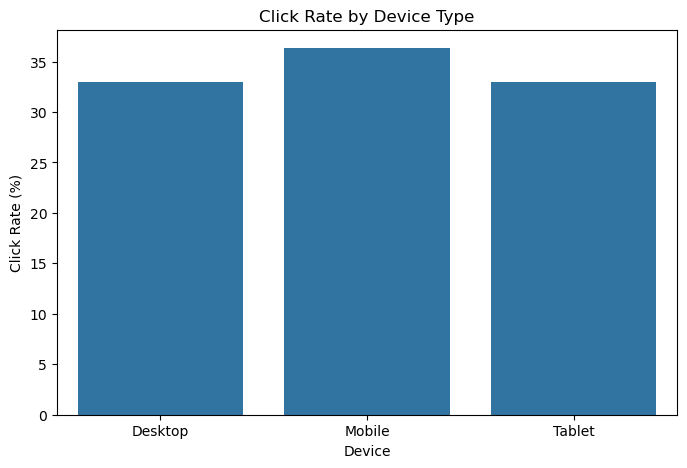

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=device_ctr.index,
    y=device_ctr.values
)

plt.title("Click Rate by Device Type")
plt.xlabel("Device")
plt.ylabel("Click Rate (%)")

plt.show()

***Click rate by campaign***

In [66]:
campaign_ctr = df.groupby("campaign_type")["click"].mean() * 100

print(campaign_ctr)

campaign_type
Awareness        33.464729
Consideration    32.691989
Conversion       36.088056
Retargeting      38.291568
Name: click, dtype: float64


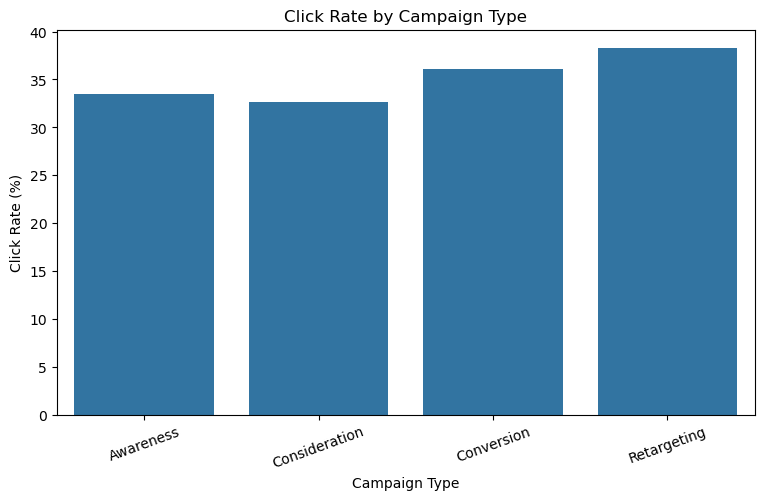

In [67]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=campaign_ctr.index,
    y=campaign_ctr.values
)

plt.title("Click Rate by Campaign Type")
plt.xlabel("Campaign Type")
plt.ylabel("Click Rate (%)")

plt.xticks(rotation=20)

plt.show()

***Click rate by ad category***

In [68]:
category_ctr = df.groupby("ad_category")["click"].mean() * 100

print(category_ctr.sort_values(ascending=False))

ad_category
Travel           35.706484
Food             35.664477
Fashion          35.556226
Finance          35.460428
Automotive       35.075297
E-commerce       34.418416
Technology       34.399684
Entertainment    34.371869
Education        34.325972
Healthcare       34.315873
Name: click, dtype: float64


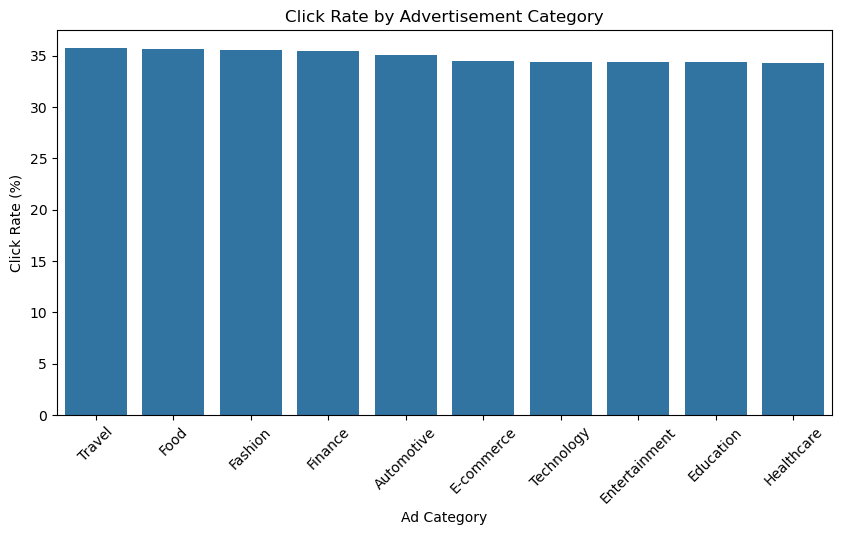

In [69]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_ctr.sort_values(ascending=False).index,
    y=category_ctr.sort_values(ascending=False).values
)

plt.title("Click Rate by Advertisement Category")
plt.xlabel("Ad Category")
plt.ylabel("Click Rate (%)")

plt.xticks(rotation=45)

plt.show()

***Click rate by ad position***

In [70]:
position_ctr = df.groupby("ad_position")["click"].mean() * 100

print(position_ctr)

ad_position
Bottom     31.968977
Middle     35.019888
Sidebar    32.267081
Top        38.460163
Name: click, dtype: float64


***Analyze user engagement***

In [71]:
engagement_features = [
    "time_on_page",
    "pages_viewed",
    "previous_clicks",
    "session_duration",
    "device_engagement"
]

df.groupby("click")[engagement_features].mean()

,time_on_page,pages_viewed,previous_clicks,session_duration,device_engagement
click,,,,,
0,43.983550,3.835825,1.188225,132.035139,50.659154
1,47.338458,4.292679,1.510750,142.407844,54.457520


***Correlation analysis***

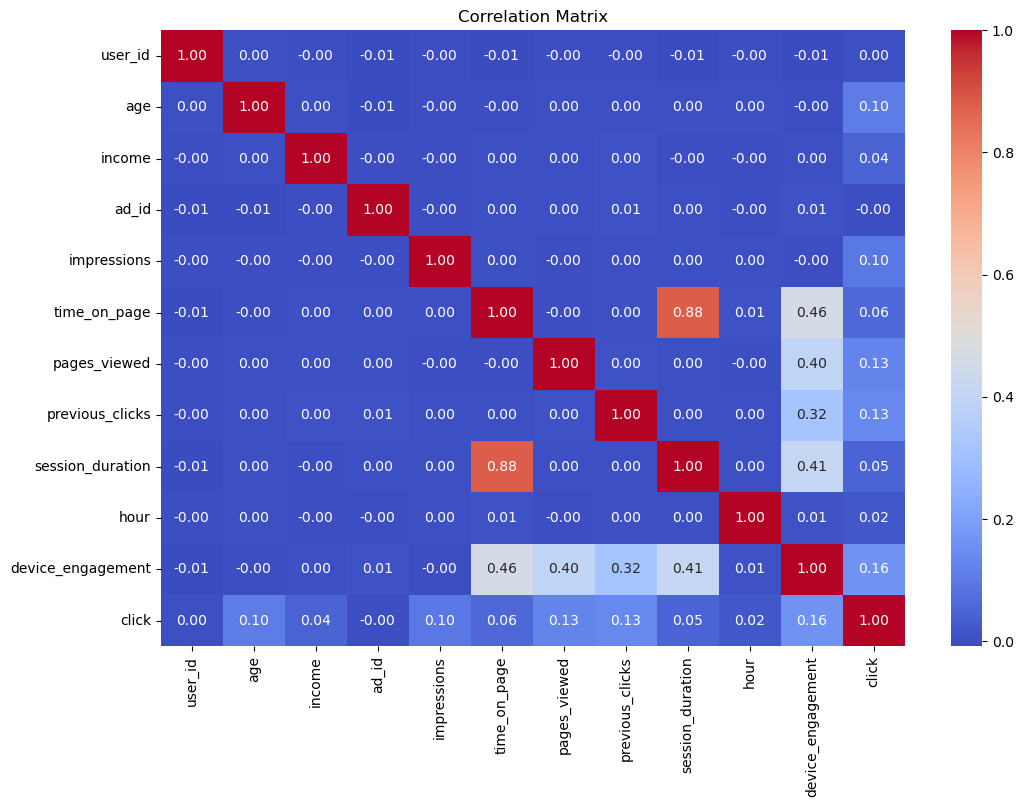

In [72]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

***Important feature decision***

In [73]:
print("Unique users:", df["user_id"].nunique())
print("Unique ads:", df["ad_id"].nunique())

Unique users: 100000
Unique ads: 150


In [74]:
print(df["ad_id"].value_counts().head(20))

ad_id
1047    720
1027    710
1082    709
1093    705
1058    705
1049    704
1040    702
1068    702
1123    702
1024    701
1066    701
1089    700
1072    700
1125    700
1076    699
1022    699
1026    698
1134    698
1149    697
1052    697
Name: count, dtype: int64


***Business Insight Statement***

*The proposed Deep Learning-based advertisement click prediction system can help businesses identify users with a higher likelihood of engaging with advertisements. By combining demographic, behavioral, device, advertisement, and campaign-related information, the system can support more targeted advertising, campaign optimization, advertisement placement decisions, and efficient allocation of marketing resources.*

**Business Recommendations**

*1: Prioritize high-probability users using the model's predicted click probability.*

*2: Optimize advertising budgets toward campaigns and segments demonstrating stronger performance.*

*3: Personalize advertisements based on user behavior, device, location, and advertisement category.*

*4: Optimize ad placement and creative strategy using data-driven CTR analysis and A/B testing*

*5: Continuously monitor and retrain the model as user behavior and campaign performance change.*

***Conclusion***

**The Deep Learning project successfully demonstrates how neural network techniques can be applied to analyze customer behavior and make accurate predictions from the given dataset. Through data preprocessing, exploratory data analysis, feature engineering, model development, training, and evaluation, the project established an end-to-end deep learning workflow.**

**The developed model can identify patterns in customer data and predict the target outcome, providing valuable insights that can support business decision-making. The project also highlights the importance of data quality, appropriate feature selection, model optimization, and performance evaluation when building reliable machine learning solutions.**

**Overall, this project shows that Deep Learning can be effectively used to transform historical customer data into actionable business insights. The model can further be improved by using larger datasets, hyperparameter tuning, advanced neural network architectures, and continuous retraining with new data. With these improvements, the solution can be integrated into real-world business applications to support proactive decision-making, improve customer retention, and enhance overall business performance.**

# Model Building — Deep Learning (Keras)

The EDA above didn't yet train a model. Before we can deploy anything, we need a trained classifier. We build a small feed-forward neural network with Keras: categorical columns are one-hot encoded, numerical columns are scaled, and `user_id` / `ad_id` are dropped (user_id is unique per row, ad_id is a high-cardinality identifier — neither generalizes well as a raw feature).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)

target = "click"
drop_cols = ["user_id", "ad_id", target]

categorical_cols = ["gender", "device_type", "browser", "location",
                     "ad_category", "ad_position", "day_of_week", "campaign_type"]
numerical_cols = ["age", "income", "impressions", "time_on_page",
                   "pages_viewed", "previous_clicks", "session_duration",
                   "hour", "device_engagement"]

X = df.drop(columns=drop_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# OneHotEncoder can return a sparse matrix - densify for Keras
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_test_proc = X_test_proc.toarray()

print("Processed training shape:", X_train_proc.shape)

### Build and Train the Neural Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

dl_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_proc.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

dl_model.summary()

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = dl_model.fit(
    X_train_proc, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

### Evaluate the Model

In [ ]:
y_pred_proba = dl_model.predict(X_test_proc).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

# Model Deployment

To deploy this model we save two artifacts: the trained Keras model, and the fitted `ColumnTransformer` (so raw incoming records get the exact same scaling/encoding used in training).

In [ ]:
import os
import joblib

os.makedirs("models", exist_ok=True)

dl_model.save("models/ad_click_model.keras")
joblib.dump(preprocessor, "models/ad_click_preprocessor.pkl")
joblib.dump(categorical_cols + numerical_cols, "models/ad_click_feature_columns.pkl")

print("Saved model, preprocessor, and feature column list.")

### Reusable Inference Function

In [ ]:
import joblib
import pandas as pd
from tensorflow.keras.models import load_model

def load_artifacts(model_path="models/ad_click_model.keras",
                    preprocessor_path="models/ad_click_preprocessor.pkl",
                    columns_path="models/ad_click_feature_columns.pkl"):
    model = load_model(model_path)
    preprocessor = joblib.load(preprocessor_path)
    feature_columns = joblib.load(columns_path)
    return model, preprocessor, feature_columns


def predict_click(record: dict, model=None, preprocessor=None, feature_columns=None, threshold=0.5):
    """
    record: dict of raw feature values, e.g.
        {
            "age": 34, "gender": "Male", "income": 55000, "device_type": "Mobile",
            "browser": "Chrome", "location": "Chennai", "ad_category": "Technology",
            "ad_position": "Top", "impressions": 5, "time_on_page": 45.2,
            "pages_viewed": 3, "previous_clicks": 1, "session_duration": 120.0,
            "hour": 14, "day_of_week": "Monday", "campaign_type": "Retargeting",
            "device_engagement": 0.7
        }
    Returns: dict with click prediction (0/1) and probability.
    """
    if model is None or preprocessor is None or feature_columns is None:
        model, preprocessor, feature_columns = load_artifacts()

    input_df = pd.DataFrame([record])[feature_columns]
    processed = preprocessor.transform(input_df)
    if hasattr(processed, "toarray"):
        processed = processed.toarray()

    probability = float(model.predict(processed, verbose=0)[0][0])
    prediction = int(probability >= threshold)

    return {
        "click_prediction": prediction,
        "click_label": "Likely to click" if prediction == 1 else "Unlikely to click",
        "click_probability": round(probability, 4)
    }

### Test the Inference Function

In [ ]:
sample_record = {
    "age": 34, "gender": "Male", "income": 55000, "device_type": "Mobile",
    "browser": "Chrome", "location": "Chennai", "ad_category": "Technology",
    "ad_position": "Top", "impressions": 5, "time_on_page": 45.2,
    "pages_viewed": 3, "previous_clicks": 1, "session_duration": 120.0,
    "hour": 14, "day_of_week": "Monday", "campaign_type": "Retargeting",
    "device_engagement": 0.7
}

model, preprocessor, feature_columns = load_artifacts()
result = predict_click(sample_record, model, preprocessor, feature_columns)
print(result)

### Deployment Option 1: Flask REST API

Writes a standalone Flask app (`deployment/app.py`) that loads the saved model and preprocessor and serves predictions at `POST /predict`. Run it **outside** the notebook.

In [ ]:
import os
os.makedirs("deployment", exist_ok=True)

In [ ]:
%%writefile deployment/app.py
"""
Flask REST API for the Ad Click Prediction model.

Run with:
    cd deployment
    python app.py

Then send a request, e.g.:
    curl -X POST http://127.0.0.1:5000/predict \
         -H "Content-Type: application/json" \
         -d '{"age":34,"gender":"Male","income":55000,"device_type":"Mobile",
              "browser":"Chrome","location":"Chennai","ad_category":"Technology",
              "ad_position":"Top","impressions":5,"time_on_page":45.2,
              "pages_viewed":3,"previous_clicks":1,"session_duration":120.0,
              "hour":14,"day_of_week":"Monday","campaign_type":"Retargeting",
              "device_engagement":0.7}'
"""
import os
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from tensorflow.keras.models import load_model

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "..", "models")

model = load_model(os.path.join(MODEL_DIR, "ad_click_model.keras"))
preprocessor = joblib.load(os.path.join(MODEL_DIR, "ad_click_preprocessor.pkl"))
feature_columns = joblib.load(os.path.join(MODEL_DIR, "ad_click_feature_columns.pkl"))

app = Flask(__name__)


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})


@app.route("/predict", methods=["POST"])
def predict():
    try:
        payload = request.get_json(force=True)
        input_df = pd.DataFrame([payload])[feature_columns]
        processed = preprocessor.transform(input_df)
        if hasattr(processed, "toarray"):
            processed = processed.toarray()

        probability = float(model.predict(processed, verbose=0)[0][0])
        prediction = int(probability >= 0.5)

        return jsonify({
            "click_prediction": prediction,
            "click_label": "Likely to click" if prediction == 1 else "Unlikely to click",
            "click_probability": round(probability, 4)
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 400


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5001, debug=True)

In [ ]:
%%writefile deployment/requirements.txt
flask
pandas
scikit-learn
joblib
tensorflow

### Deployment Option 2: Streamlit App

Run with `streamlit run deployment/streamlit_app.py` from the project root (outside this notebook).

In [ ]:
%%writefile deployment/streamlit_app.py
"""
Streamlit app for the Ad Click Prediction model.

Run with:
    streamlit run deployment/streamlit_app.py
"""
import os
import joblib
import pandas as pd
import streamlit as st
from tensorflow.keras.models import load_model

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_DIR = os.path.join(BASE_DIR, "..", "models")

model = load_model(os.path.join(MODEL_DIR, "ad_click_model.keras"))
preprocessor = joblib.load(os.path.join(MODEL_DIR, "ad_click_preprocessor.pkl"))
feature_columns = joblib.load(os.path.join(MODEL_DIR, "ad_click_feature_columns.pkl"))

st.title("Ad Click Predictor")
st.write("Enter user/session details to predict the likelihood of an ad click.")

with st.form("click_form"):
    age = st.number_input("Age", min_value=0, value=30)
    gender = st.selectbox("Gender", ["Male", "Female", "Other"])
    income = st.number_input("Income", min_value=0, value=50000)
    device_type = st.selectbox("Device Type", ["Mobile", "Desktop", "Tablet"])
    browser = st.selectbox("Browser", ["Chrome", "Safari", "Firefox", "Edge", "Opera"])
    location = st.text_input("Location", value="Chennai")
    ad_category = st.text_input("Ad Category", value="Technology")
    ad_position = st.text_input("Ad Position", value="Top")
    impressions = st.number_input("Impressions", min_value=0, value=5)
    time_on_page = st.number_input("Time on Page (sec)", min_value=0.0, value=45.0)
    pages_viewed = st.number_input("Pages Viewed", min_value=0, value=3)
    previous_clicks = st.number_input("Previous Clicks", min_value=0, value=1)
    session_duration = st.number_input("Session Duration (sec)", min_value=0.0, value=120.0)
    hour = st.slider("Hour of Day", 0, 23, 14)
    day_of_week = st.selectbox("Day of Week",
        ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    campaign_type = st.text_input("Campaign Type", value="Retargeting")
    device_engagement = st.slider("Device Engagement", 0.0, 1.0, 0.7)

    submitted = st.form_submit_button("Predict")

if submitted:
    record = {
        "age": age, "gender": gender, "income": income, "device_type": device_type,
        "browser": browser, "location": location, "ad_category": ad_category,
        "ad_position": ad_position, "impressions": impressions, "time_on_page": time_on_page,
        "pages_viewed": pages_viewed, "previous_clicks": previous_clicks,
        "session_duration": session_duration, "hour": hour, "day_of_week": day_of_week,
        "campaign_type": campaign_type, "device_engagement": device_engagement
    }
    input_df = pd.DataFrame([record])[feature_columns]
    processed = preprocessor.transform(input_df)
    if hasattr(processed, "toarray"):
        processed = processed.toarray()
    probability = float(model.predict(processed, verbose=0)[0][0])

    if probability >= 0.5:
        st.success(f"Likely to click (probability: {probability:.2%})")
    else:
        st.info(f"Unlikely to click (probability: {probability:.2%})")